## Predicting Gibbs free energy of solvation using random forest, SVM and linear regression models

In [2]:
# imports
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

#####  This [research study](https://pubs.acs.org/doi/10.1021/acs.jcim.3c00544) implemented different classification methods and came up with their own feature selection and ensemble method for classification.

### Data Initialization
   Solvent Type is composed of strings and the authors of the paper removed this column on their code that they published on their github. This information is likely not critical, and it will cause math errors and its only good for data visualization. We replace all NaN values with zero since SVM and model cannot handle NaN values. Why we use standard scaler is because the magnitude of the features needs to be scaled to same order for the SVM and linear regression models for the weights to not be weighted

In [ ]:
# initial import of the given CSV file
df = pd.read_csv('Gibbs_predictor_498_data_final.csv')
target = df['gibbs_free_energy']
data = df.drop('gibbs_free_energy', axis=1)
solvent_types = data # for final question
data = data.drop('Solvent_Type', axis=1) # this column is only for graphing purposes

# fill all NaN values with 0 since NaN will not be accepted as inputs for algorithms
data = data.fillna(0)
target = target.fillna(0)

# split the data into train and test segments, also scale the data
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)
X_names, X_test_names= train_test_split(solvent_types, test_size=0.2, random_state=42)

# scale dataset
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

Regression models are used because the gibbs energy of solvation are composed of numerical values, so classification would not be appropriate for this numerical output.

In [9]:
# first begin by separating test and validation data
y_validation, y_test = train_test_split(y_test, test_size=0.5, random_state=42)
x_validation, x_test = train_test_split(X_test_scaled, test_size=0.5, random_state=42)
x_validation_names, x_test_names = train_test_split(X_test_names, test_size=0.5, random_state=42)
    #note that x_test is already scaled and is final test dataset

In [39]:
# Next Run through the 3 algorithms, all hyperparameters were provided earlier
#linear model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Support Vector (Regression)
svm = SVR(kernel='rbf', C=10)
svm.fit(X_train_scaled, y_train)

# Random Forest (Regression)
rlf = RandomForestRegressor(n_estimators=250, min_samples_split=2, max_features='sqrt', min_samples_leaf=1, bootstrap=False)
rlf.fit(X_train_scaled, y_train)

RandomForestRegressor(bootstrap=False, max_features='sqrt', n_estimators=250)

In [11]:
#creating empty lists for columns later used for output
algorithm = [linear_model, svm, rlf]
test_scores =  []
mean_absolute_error = []
stdev = []

In [12]:
for i in range (len(algorithm)):

    #using cross validation to obtain the mean absolute error of each algorithm
    mae_temp = cross_val_score(algorithm[i], x_validation, y_validation, cv = 10, verbose = 1, scoring = 'neg_mean_absolute_error')
    #getting test score, which is the R^2 value of test
    test_scores.append(algorithm[i].score(x_validation, y_validation))
    #getting the mean absolute error through averaging the array of mean absolute errors from our cross validation
    mean_absolute_error.append(-np.average(mae_temp))
    stdev.append(np.std(mae_temp))

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    5.4s finished


In [13]:
# Outputting to CSV file
output = pd.DataFrame({'algorithm':['Linear Model','SVM','RandomForest'],'test score':test_scores,'mean absolute error':mean_absolute_error,'standard deviation of mean absolute error':stdev})
output.to_csv('output.csv',index=False)

(0.0, 2.0)

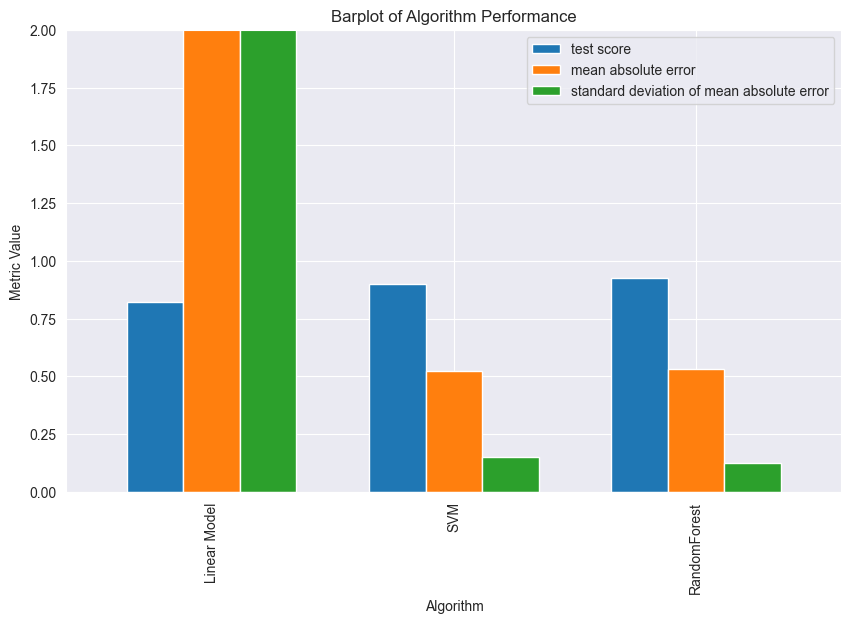

In [ ]:
# Plotting resulting model performance

plot_data = output.set_index('algorithm')
# Creating a grouped bar plot
ax = plot_data.plot(kind='bar', figsize=(10, 6), width=0.7)

plt.title('Barplot of Algorithm Performance')
plt.xlabel('Algorithm')
plt.ylabel('Metric Value')
plt.legend()

#setting a limit for the y-axis so that all values are visible and not just the extremely large ones.
plt.ylim(0,2)

In [40]:
# calculating permutation importance for all 3 models
linear_importance = permutation_importance(linear_model, x_validation, y_validation, n_repeats=5)
svm_importance = permutation_importance(svm, x_validation, y_validation, n_repeats=5)
rf_importance = permutation_importance(rlf, x_validation, y_validation, n_repeats=5)
    # we chose 5 repeats because there was some variance when rerunning this code with slightly different features showing up, so we did with 3 repeats but 5 would be ideal but computation time would take a long

In [41]:
# lists of top features with n referring to number of elements
n=10
top_features_linear = []
top_features_svr = []
top_features_rf = []

In [42]:
# sort lists from highest to lowest importance than take top 10 features
lin_mean = linear_importance.importances_mean
lin_sorted = np.sort(lin_mean)[::-1]
top_features_linear = lin_sorted[:n]

svr_mean = svm_importance.importances_mean
svr_sorted = np.sort(svr_mean)[::-1]
top_features_svr = svr_sorted[:n]

rf_mean = rf_importance.importances_mean
rf_sorted = np.sort(rf_mean)[::-1]
top_features_rf = rf_sorted[:n]

In [43]:
idx_lin = []
idx_svr = []
idx_rf = []

#get indexes of all important features
for k in top_features_linear:
    idx_lin.append(np.where(lin_mean == k))
for j in top_features_svr:
    idx_svr.append(np.where(svr_mean == j))
for m in top_features_rf:
    idx_rf.append(np.where(rf_mean == m))

In [44]:
column_name_lin = []
column_name_svr = []
column_name_rf = []

# get feature names
for i in idx_lin:
    column_name_lin.append(data.columns[i].item())
for j in idx_svr:
    column_name_svr.append(data.columns[j].item())
for m in idx_rf:
    column_name_rf.append(data.columns[m].item())

Text(0, 0.5, 'Mean Importance')

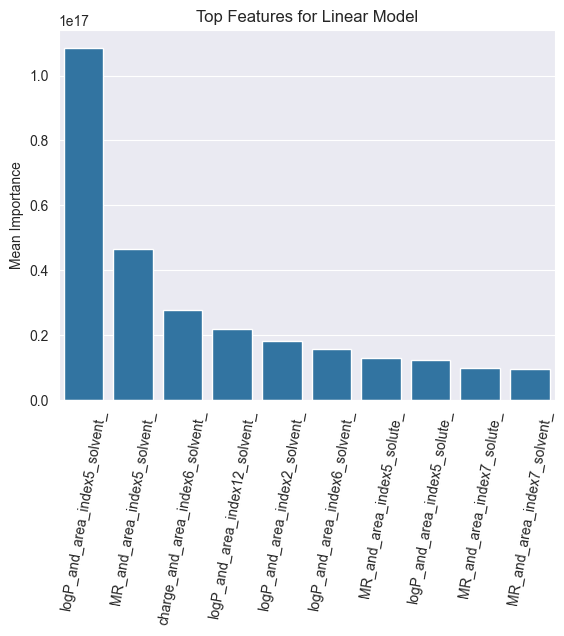

In [45]:
# feature importnace graph for linear model
sns.barplot(x= column_name_lin, y=top_features_linear)
plt.xticks(rotation=80)
plt.title('Top Features for Linear Model')
plt.ylabel('Mean Importance')

Text(0, 0.5, 'Mean Importance')

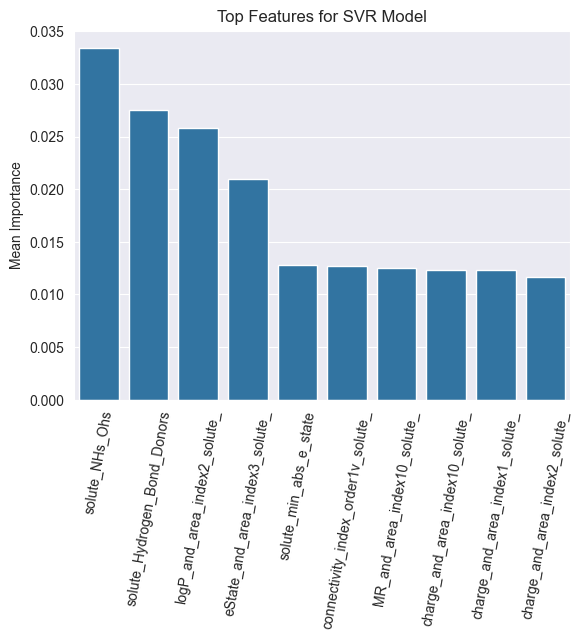

In [46]:
#feature importnace svr
sns.barplot(x=column_name_svr, y=top_features_svr)
plt.xticks(rotation=80)
plt.title('Top Features for SVR Model')
plt.ylabel('Mean Importance')

Text(0, 0.5, 'Mean Importance')

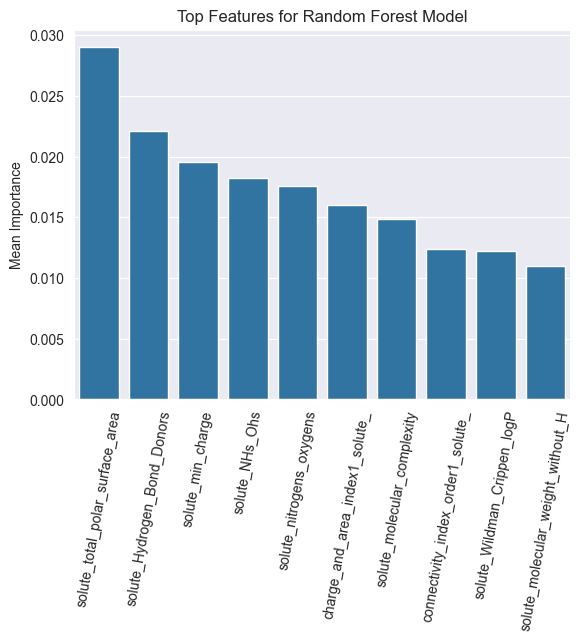

In [47]:
#feature importance for Random Forest
sns.barplot(x=column_name_rf, y=top_features_rf)
plt.xticks(rotation=80)
plt.title('Top Features for Random Forest Model')
plt.ylabel('Mean Importance')

In [31]:
# Select only the top features for the random forest model
X_train_adjusted = X_train[column_name_rf]
X_test_adjusted = X_test[column_name_rf]

#scaling
X_train_adjusted_scaled = sc.fit_transform(X_train_adjusted)
X_test_adjusted_scaled = sc.transform(X_test_adjusted)

#spliting into validation and test set for re-running and comparing results
x_validation_split, x_test_adjusted = train_test_split(X_test_adjusted_scaled, test_size = 0.5, random_state = 42)

In [32]:
#linear model
linear_model_adj = LinearRegression()
linear_model_adj.fit(X_train_adjusted_scaled, y_train)

# Support Vector (Regression)
svm_adj = SVR(kernel='rbf', C=10)
svm_adj.fit(X_train_adjusted_scaled, y_train)

# Random Forest (Regression)
rlf_adj = RandomForestRegressor(n_estimators=250, min_samples_split=2, min_samples_leaf=1, bootstrap=False)
rlf_adj.fit(X_train_adjusted_scaled, y_train)

RandomForestRegressor(bootstrap=False, n_estimators=250)

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    3.5s finished


(0.0, 2.0)

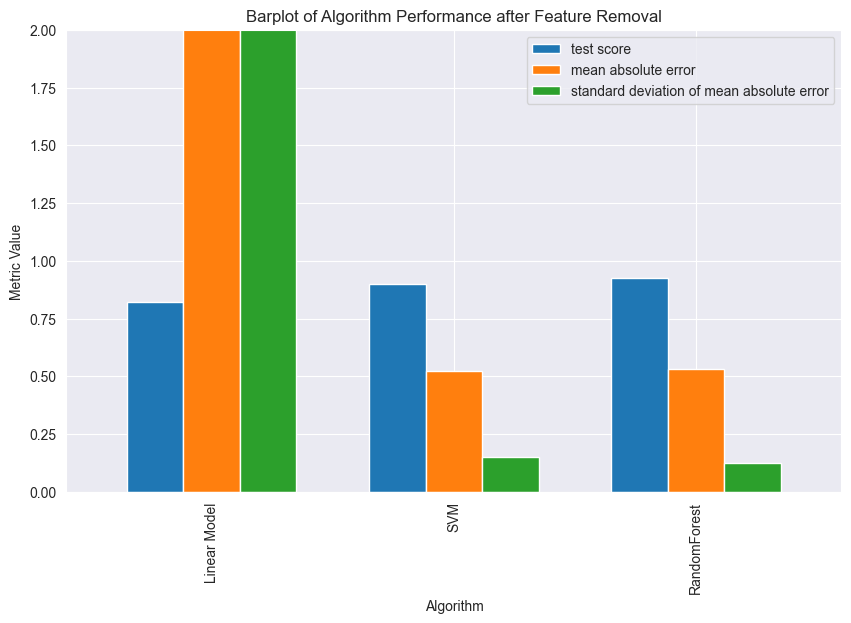

In [37]:
#creating empty lists for columns later used for output
algorithm = [linear_model_adj, svm_adj, rlf_adj]
test_scores =  []
mean_absolute_error = []
stdev = []

for i in range (len(algorithm)):

    #using cross validation to obtain the mean absolute error of each algorithm
    mae_temp = cross_val_score(algorithm[i], x_validation_split, y_validation, cv = 10, verbose = 1, scoring = 'neg_mean_absolute_error')
    #getting test score, which is the R^2 value of test
    test_scores.append(algorithm[i].score(x_validation_split, y_validation))
    #getting the mean absolute error through averaging the array of mean absolute errors from our cross validation
    mean_absolute_error.append(-np.average(mae_temp))
    stdev.append(np.std(mae_temp))

# Plotting Question 4

plot_data = output.set_index('algorithm')
# Creating a grouped bar plot
ax = plot_data.plot(kind='bar', figsize=(10, 6), width=0.7)

plt.title('Barplot of Algorithm Performance after Feature Removal')
plt.xlabel('Algorithm')
plt.ylabel('Metric Value')
plt.legend()

#setting a limit for the y-axis so that all values are visible and not just the extremely large ones.
plt.ylim(0,2)

Using only the top 10 features result in very similar results as in the entire 213 feature dataset. These features must represent all the variance.

In [34]:
# find predicted values from the random forest
gibbs_predict = rlf_adj.predict(x_test_adjusted)

Text(0, 0.5, 'Predicted Gibbs Energy')

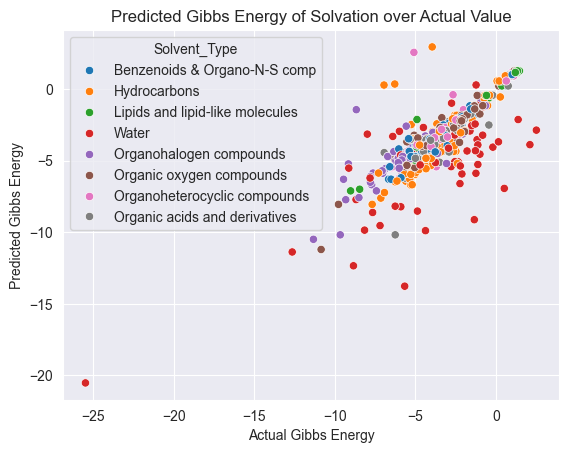

In [35]:
# plotting results
sns.scatterplot(data=x_test_names, x=y_test, y=gibbs_predict, hue='Solvent_Type')
plt.title('Predicted Gibbs Energy of Solvation over Actual Value')
plt.xlabel('Actual Gibbs Energy')
plt.ylabel('Predicted Gibbs Energy')